1. Import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Upload the cleaned dataset
from google.colab import files
uploaded = files.upload()


Saving Cleaned_Dataset.xlsx to Cleaned_Dataset.xlsx


2. Load the dataset

In [3]:
df = pd.read_excel("Cleaned_Dataset.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1200, 14)


3. Display basic information about the dataset

In [4]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1200, 14)

Column Names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


4. Display the first 5 records

In [5]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


5. Basic statistics for numerical columns

In [6]:
numerical_columns = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

basic_stats = pd.DataFrame({
    'Count': df[numerical_columns].count(),
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median()
})

basic_stats

,Count,Mean,Median
Quantity,1200,2.945833,3.000
UnitPrice,1200,356.412750,364.210
ItemsInCart,1200,5.485000,5.000
TotalPrice,1200,1053.968300,823.615


6. Analyze the Distributions

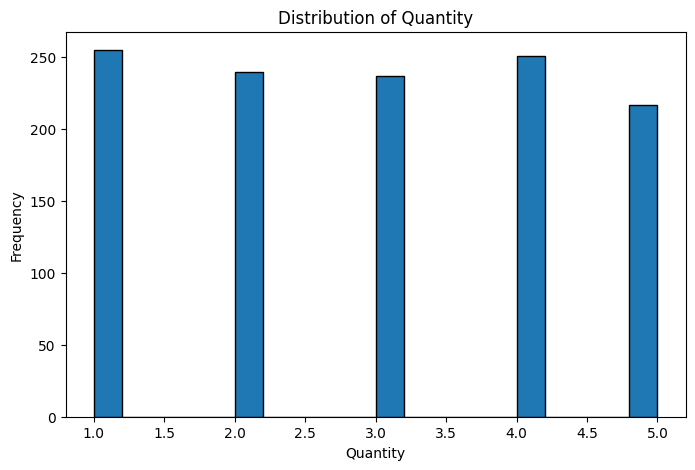

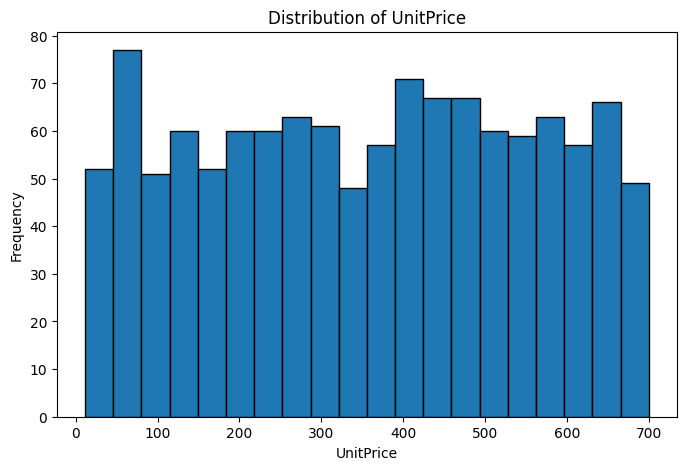

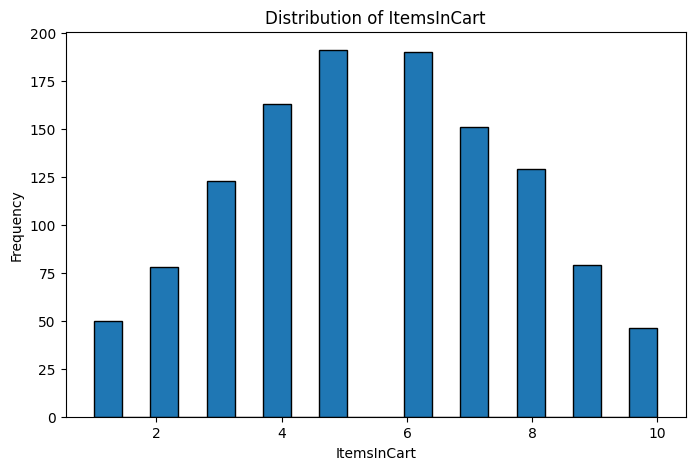

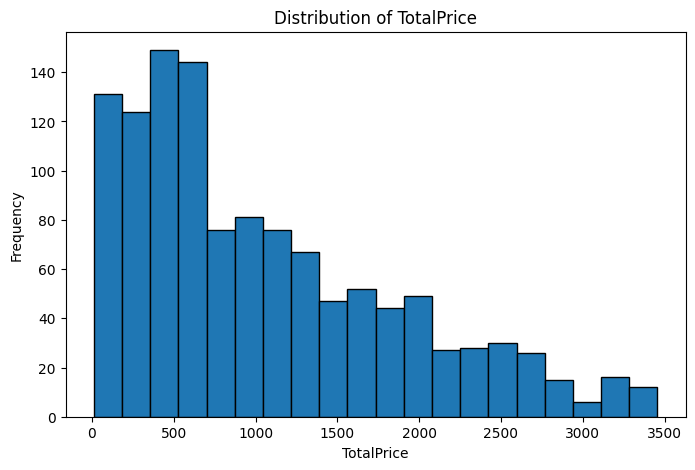

In [7]:

numerical_columns = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column], bins=20, edgecolor='black')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()
    print()

7. Detect Outliers Using IQR

In [8]:


numerical_columns = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Quantity,2.0000,4.000,2.0000,-1.00000,7.00000,0
1,UnitPrice,186.0625,521.570,335.5075,-317.19875,1024.83125,0
2,ItemsInCart,4.0000,7.000,3.0000,-0.50000,11.50000,0
3,TotalPrice,410.5200,1578.475,1167.9550,-1341.41250,3330.40750,8


8. Inspect the TotalPrice Outliers

In [9]:
# Display the potential TotalPrice outliers

Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

totalprice_outliers = df[df['TotalPrice'] > upper_bound]

totalprice_outliers[
    ['OrderID', 'Date', 'Product', 'Quantity',
     'UnitPrice', 'OrderStatus', 'CouponCode', 'TotalPrice']
].sort_values('TotalPrice', ascending=False)

,OrderID,Date,Product,Quantity,UnitPrice,OrderStatus,CouponCode,TotalPrice
789,ORD200789,2023-08-17,Tablet,5,691.28,Delivered,SAVE10,3456.40
1122,ORD201122,2023-06-07,Monitor,5,678.19,Returned,Unknown,3390.95
632,ORD200632,2023-05-02,Laptop,5,678.16,Delivered,WINTER15,3390.80
469,ORD200469,2023-11-26,Chair,5,676.98,Cancelled,Unknown,3384.90
328,ORD200328,2023-02-28,Tablet,5,674.04,Cancelled,SAVE10,3370.20
107,ORD200107,2023-03-27,Printer,5,670.75,Shipped,FREESHIP,3353.75
326,ORD200326,2024-07-01,Laptop,5,670.48,Returned,SAVE10,3352.40
1065,ORD201065,2023-10-30,Printer,5,666.80,Delivered,SAVE10,3334.00


9. Analyze Categorical Variables

In [10]:
categorical_columns = [
    'Product',
    'PaymentMethod',
    'OrderStatus',
    'CouponCode',
    'ReferralSource'
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Product ---
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

--- OrderStatus ---
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

--- CouponCode ---
CouponCode
FREESHIP    313
Unknown     309
WINTER15    292
SAVE10      286
Name: count, dtype: int64

--- ReferralSource ---
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


10. Visualize Categorical Distributions

/tmp/ipykernel_6682/3487302667.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="bright")


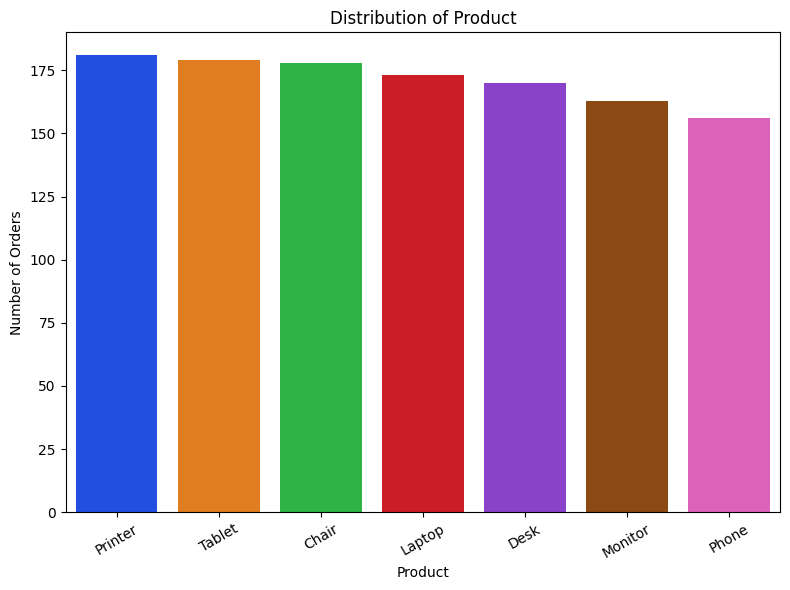

/tmp/ipykernel_6682/3487302667.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="bright")


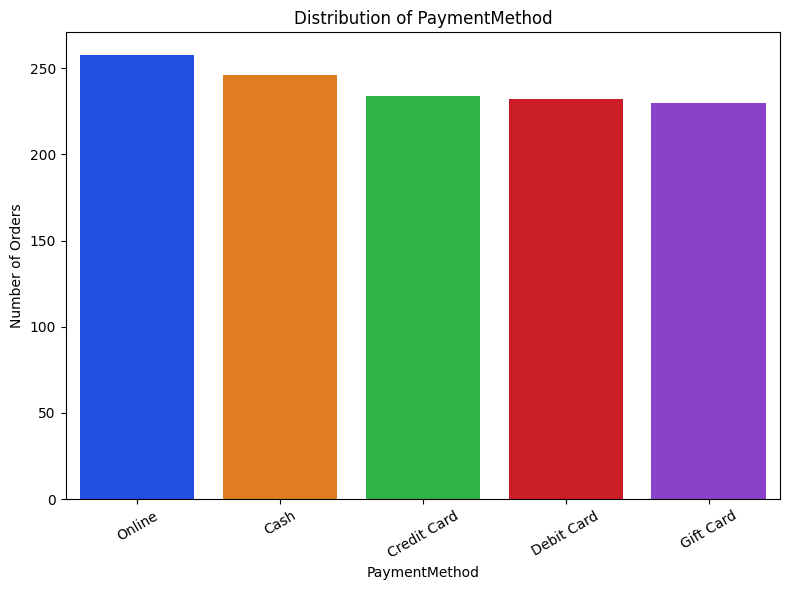

/tmp/ipykernel_6682/3487302667.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="bright")


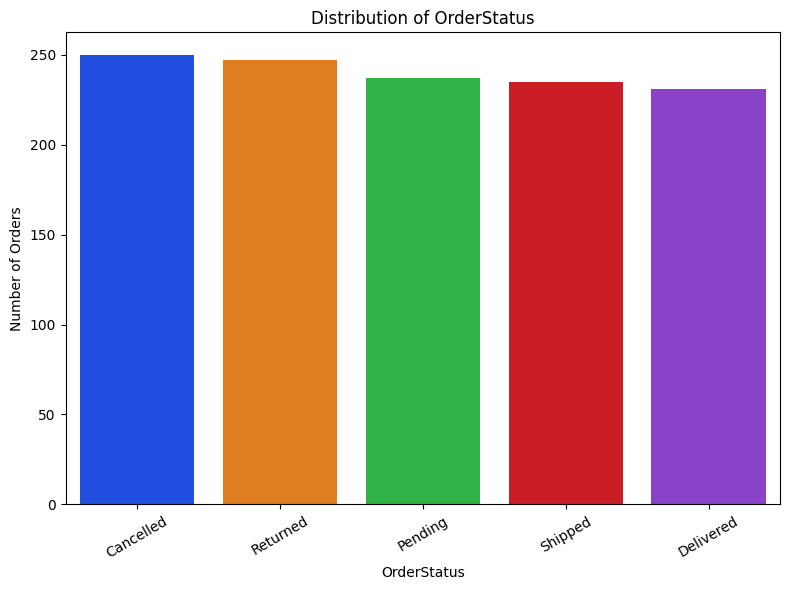

/tmp/ipykernel_6682/3487302667.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="bright")


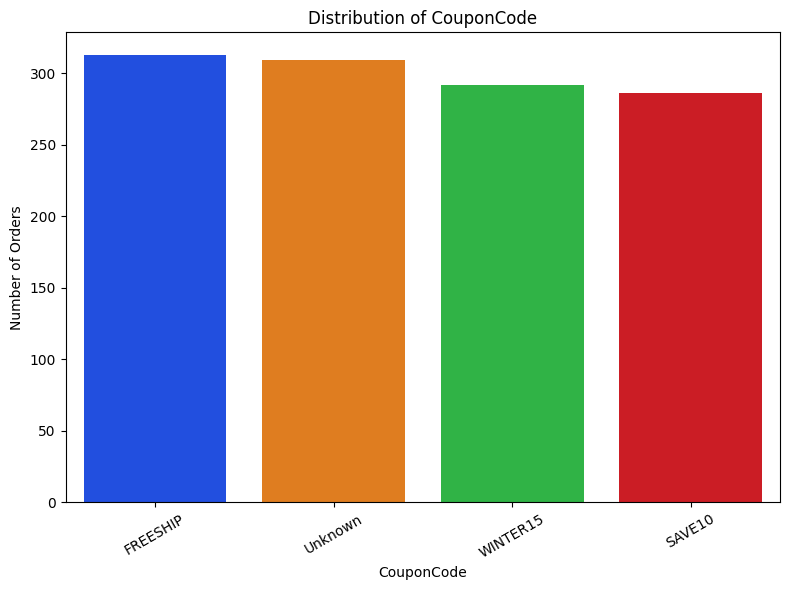

/tmp/ipykernel_6682/3487302667.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="bright")


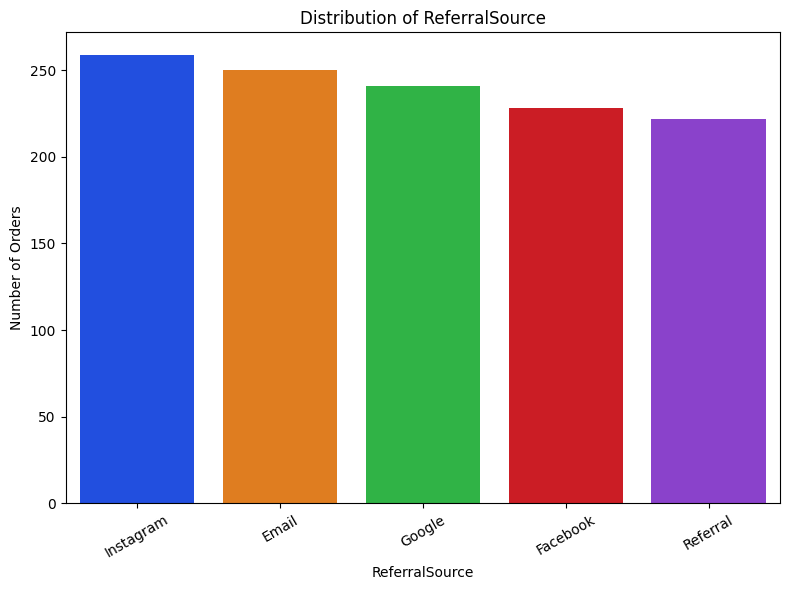

In [11]:
categorical_columns = [
    'Product',
    'PaymentMethod',
    'OrderStatus',
    'CouponCode',
    'ReferralSource'
]

for column in categorical_columns:
    plt.figure(figsize=(8, 6))

    counts = df[column].value_counts()
    sns.barplot(x=counts.index, y=counts.values, palette="bright")
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Number of Orders')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    print()

11. Analyze Order Trends Over Time

In [12]:
# Create monthly order counts
monthly_orders = (
    df.set_index('Date')
      .resample('ME')
      .size()
)
print(monthly_orders)

Date
2023-01-31    47
2023-02-28    37
2023-03-31    43
2023-04-30    31
2023-05-31    49
2023-06-30    45
2023-07-31    44
2023-08-31    51
2023-09-30    29
2023-10-31    47
2023-11-30    41
2023-12-31    46
2024-01-31    32
2024-02-29    32
2024-03-31    36
2024-04-30    50
2024-05-31    34
2024-06-30    53
2024-07-31    43
2024-08-31    28
2024-09-30    44
2024-10-31    31
2024-11-30    35
2024-12-31    41
2025-01-31    27
2025-02-28    37
2025-03-31    49
2025-04-30    32
2025-05-31    37
2025-06-30    49
Freq: ME, dtype: int64


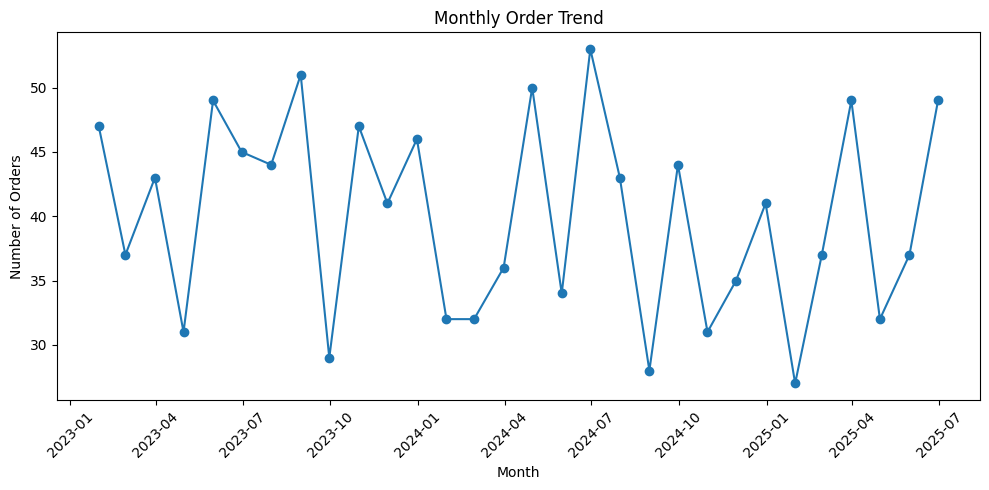

In [13]:
# Visualize monthly order trends
plt.figure(figsize=(10, 5))

plt.plot(monthly_orders.index, monthly_orders.values, marker='o')

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

12. Compare Orders Across Years

In [14]:
# Year-wise order analysis
yearly_orders = df['Date'].dt.year.value_counts().sort_index()

print("Orders by Year:")
print(yearly_orders)

Orders by Year:
Date
2023    510
2024    459
2025    231
Name: count, dtype: int64


/tmp/ipykernel_6682/2684350997.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_orders.index.astype(str), y=yearly_orders.values, palette="pastel")


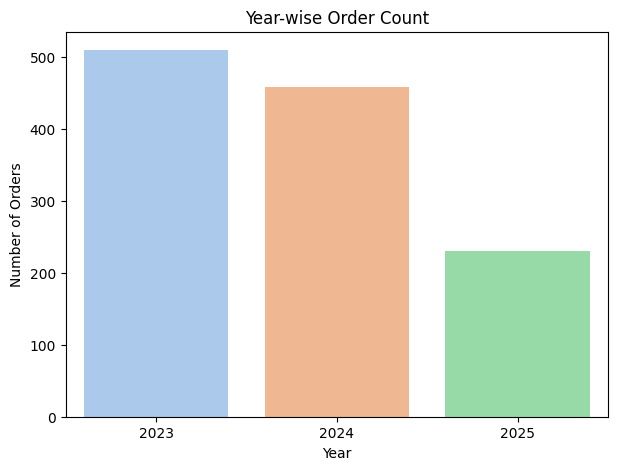

In [15]:
# Visualize yearly order counts

plt.figure(figsize=(7, 5))

sns.barplot(x=yearly_orders.index.astype(str), y=yearly_orders.values, palette="pastel")

plt.title('Year-wise Order Count')
plt.xlabel('Year')
plt.ylabel('Number of Orders')

plt.show()

Order volume was highest in 2023 with 510 orders and decreased to 459 orders in 2024. The dataset contains only six months of 2025 data, with 231 orders, so a full-year comparison for 2025 is not appropriate.

13. Analyze Sales/Revenue Trends

In [16]:
# Calculate yearly sales
yearly_sales = (
    df.groupby(df['Date'].dt.year)['TotalPrice']
      .sum()
)

print("Total Sales by Year:")
print(yearly_sales)

Total Sales by Year:
Date
2023    552643.24
2024    480235.87
2025    231882.85
Name: TotalPrice, dtype: float64


/tmp/ipykernel_6682/181413955.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_sales.index.astype(str), y=yearly_sales.values, palette=colors)


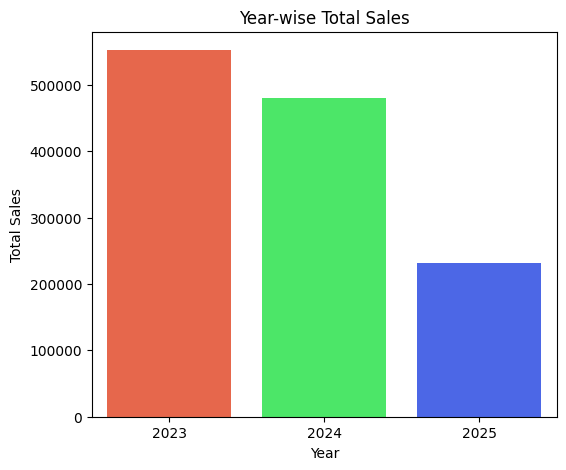

In [17]:
# Visualize yearly sales

plt.figure(figsize=(6, 5))
colors=  ['#FF5733', '#33FF57', '#3357FF']
sns.barplot(x=yearly_sales.index.astype(str), y=yearly_sales.values, palette=colors)
plt.title('Year-wise Total Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.show()

Total sales were highest in 2023 at ₹552,643.24 and decreased to ₹480,235.87 in 2024. The 2025 total of ₹231,882.85 represents only the first six months and therefore should not be directly compared with the full-year totals.

14. Compare Average Order Value by Year

In [18]:
# Calculate average order value by year

yearly_avg_order_value = (
    df.groupby(df['Date'].dt.year)['TotalPrice']
      .mean()
)

print("Average Order Value by Year:")
print(yearly_avg_order_value)

Average Order Value by Year:
Date
2023    1083.614196
2024    1046.265512
2025    1003.821861
Name: TotalPrice, dtype: float64


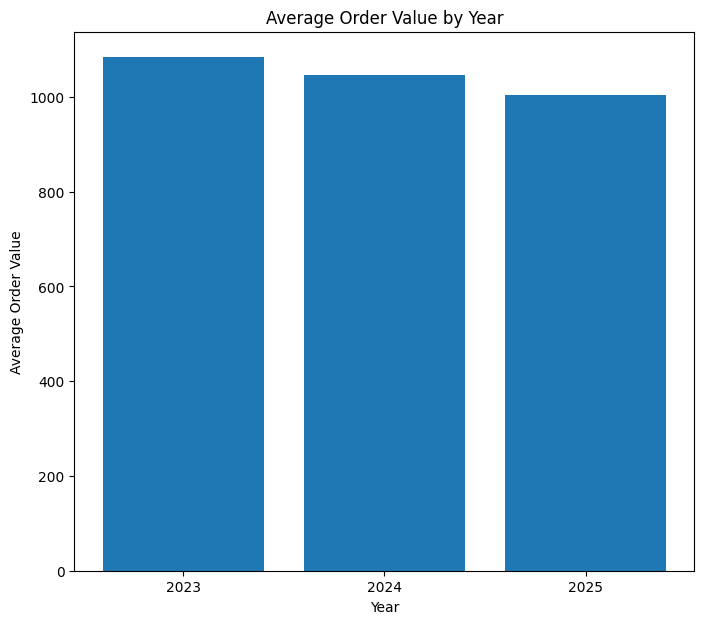

In [19]:
# Visualize average order value by year

plt.figure(figsize=(8,7))

plt.bar(
    yearly_avg_order_value.index.astype(str),
    yearly_avg_order_value.values
)

plt.title('Average Order Value by Year')
plt.xlabel('Year')
plt.ylabel('Average Order Value')

plt.show()

The average order value decreased from ₹1,083.61 in 2023 to ₹1,046.27 in 2024. The average for January–June 2025 was ₹1,003.82, suggesting a gradual decline in order value within the available period.

15. Analyze Sales by Product

In [20]:
# Calculate sales and order count by product

product_analysis = df.groupby('Product').agg(
    Order_Count=('OrderID', 'count'),
    Total_Sales=('TotalPrice', 'sum'),
    Average_Order_Value=('TotalPrice', 'mean')
).sort_values('Total_Sales', ascending=False)

product_analysis

,Order_Count,Total_Sales,Average_Order_Value
Product,,,
Chair,178,195620.11,1098.989382
Printer,181,195612.61,1080.732652
Laptop,173,192126.56,1110.558150
Tablet,179,186568.95,1042.284637
Monitor,163,175651.41,1077.616012
Desk,170,167459.93,985.058412
Phone,156,151722.39,972.579423


16. Visualize Product Performance

/tmp/ipykernel_6682/1976723223.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


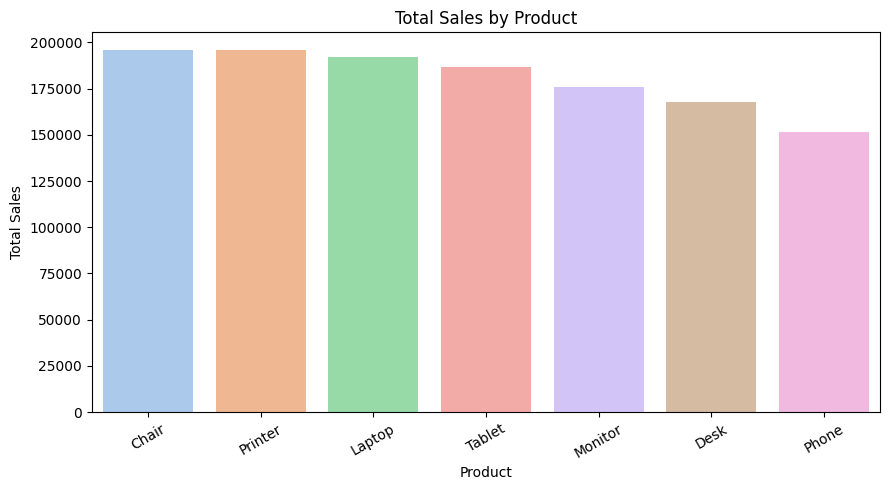

In [21]:
# Visualize total sales by product

plt.figure(figsize=(9, 5))

sns.barplot(
    x=product_analysis.index,
    y=product_analysis['Total_Sales'],
    palette='pastel'
)

plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6682/1043065823.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


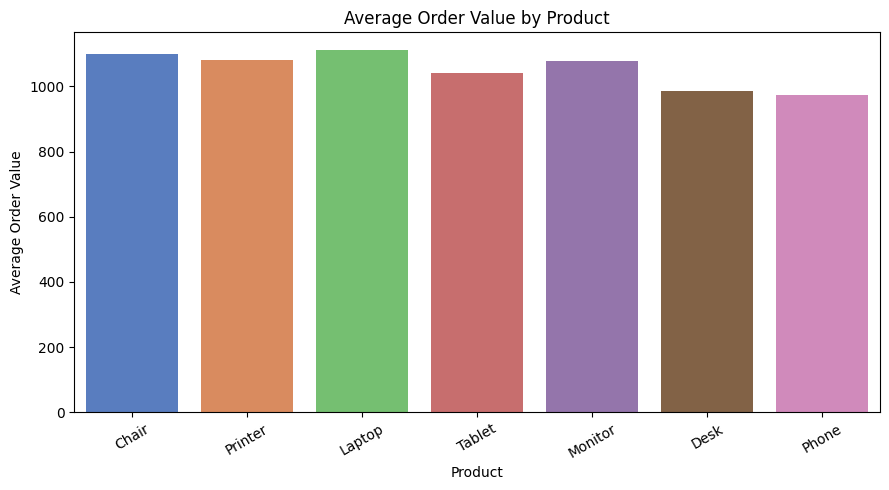

In [22]:
# Visualize average order value by product

plt.figure(figsize=(9, 5))

sns.barplot(
    x=product_analysis.index,
    y=product_analysis['Average_Order_Value'],
    palette='muted'
)

plt.title('Average Order Value by Product')
plt.xlabel('Product')
plt.ylabel('Average Order Value')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

17. Analyze Payment Methods

In [23]:
# Analyze sales performance by payment method

payment_analysis = df.groupby('PaymentMethod').agg(
    Order_Count=('OrderID', 'count'),
    Total_Sales=('TotalPrice', 'sum'),
    Average_Order_Value=('TotalPrice', 'mean')
).sort_values('Total_Sales', ascending=False)

payment_analysis

,Order_Count,Total_Sales,Average_Order_Value
PaymentMethod,,,
Credit Card,234,263847.63,1127.553974
Online,258,262442.94,1017.220698
Cash,246,259786.29,1056.041829
Gift Card,230,246323.92,1070.973565
Debit Card,232,232361.18,1001.556810


Credit Card transactions generated the highest total sales and had the highest average order value, while Online payments accounted for the largest number of orders. Debit Card transactions had the lowest total sales and average order value.

18. Visualize Payment Method Performance

/tmp/ipykernel_6682/89160822.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


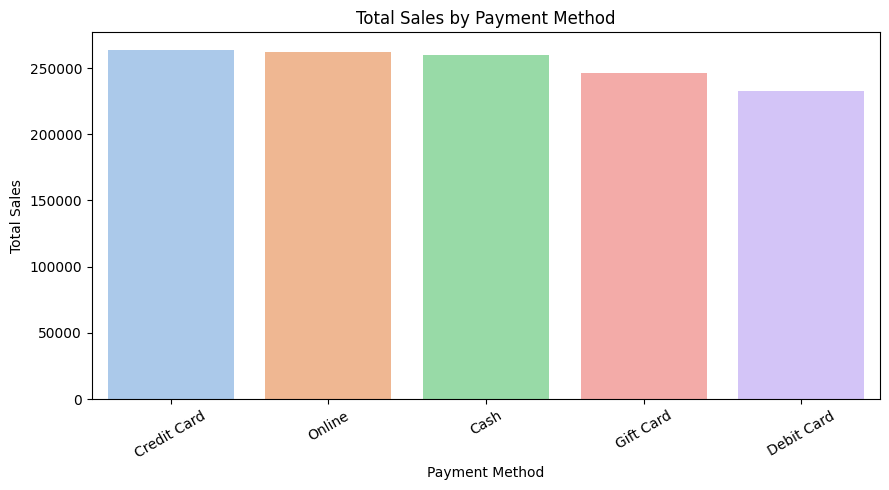

In [24]:
# Total sales by payment method

plt.figure(figsize=(9, 5))

sns.barplot(
    x=payment_analysis.index,
    y=payment_analysis['Total_Sales'], palette='pastel'
)

plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6682/1488433052.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


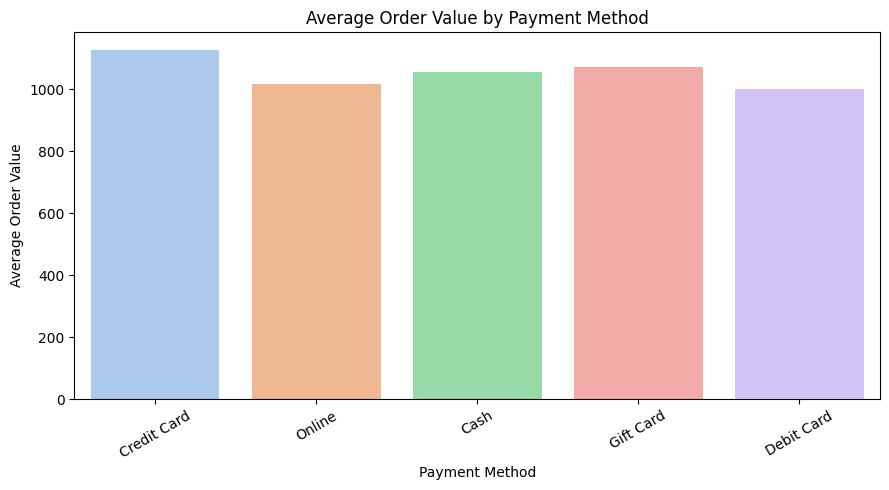

In [25]:
# Average order value by payment method

plt.figure(figsize=(9, 5))

sns.barplot(
    x=payment_analysis.index,
    y=payment_analysis['Average_Order_Value'],palette='pastel'
)

plt.title('Average Order Value by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Order Value')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

19. Analyze the Order Status

In [26]:
# Analyze sales performance by order status

status_analysis = df.groupby('OrderStatus').agg(
    Order_Count=('OrderID', 'count'),
    Total_Sales=('TotalPrice', 'sum'),
    Average_Order_Value=('TotalPrice', 'mean')
).sort_values('Total_Sales', ascending=False)

status_analysis

,Order_Count,Total_Sales,Average_Order_Value
OrderStatus,,,
Cancelled,250,276396.21,1105.584840
Pending,237,256328.15,1081.553376
Shipped,235,246159.58,1047.487574
Returned,247,243277.70,984.929960
Delivered,231,242600.32,1050.217835


Order statuses are relatively balanced in terms of order count. Cancelled orders have the highest total order value and average order value, while returned orders have the lowest average order value. Since the dataset does not provide realized-revenue information, these values represent order values rather than confirmed revenue.


20. Visualize Order Status

/tmp/ipykernel_6682/144396277.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


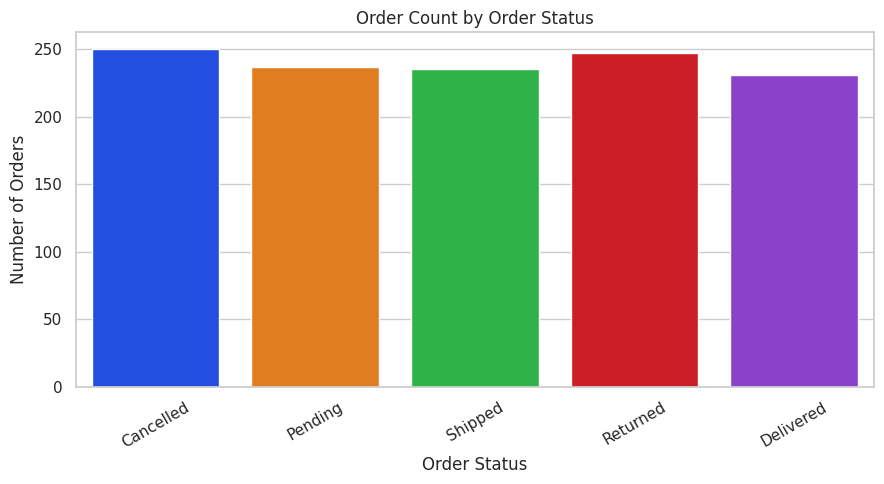

In [45]:
# Order count by order status

plt.figure(figsize=(9, 5))

sns.barplot(
    x=status_analysis.index,
    y=status_analysis['Order_Count'], palette='bright'
)

plt.title('Order Count by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6682/418330340.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


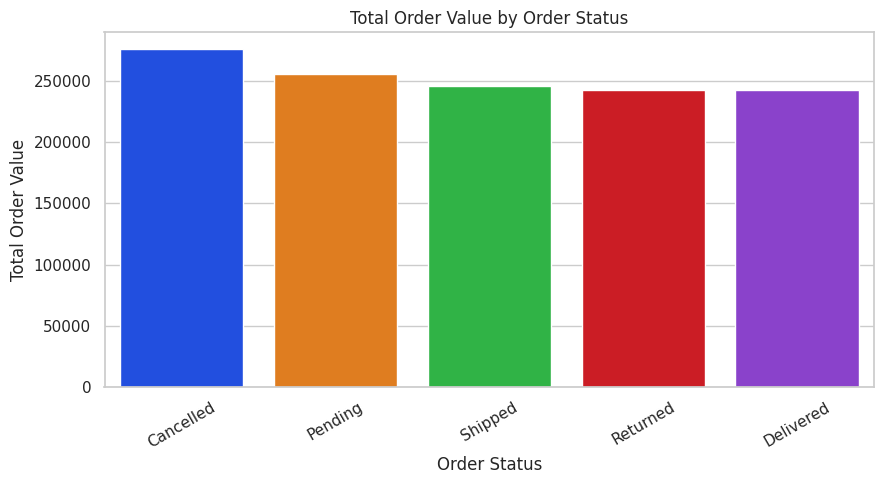

In [46]:
# Total order value by order status

plt.figure(figsize=(9, 5))

sns.barplot(
    x=status_analysis.index,
    y=status_analysis['Total_Sales'], palette='bright'
)

plt.title('Total Order Value by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Total Order Value')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

21. Analyze Relationships Between Numerical Variables

In [47]:
# Correlation between numerical variables

numerical_columns = [
    'Quantity',
    'UnitPrice',
    'ItemsInCart',
    'TotalPrice'
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


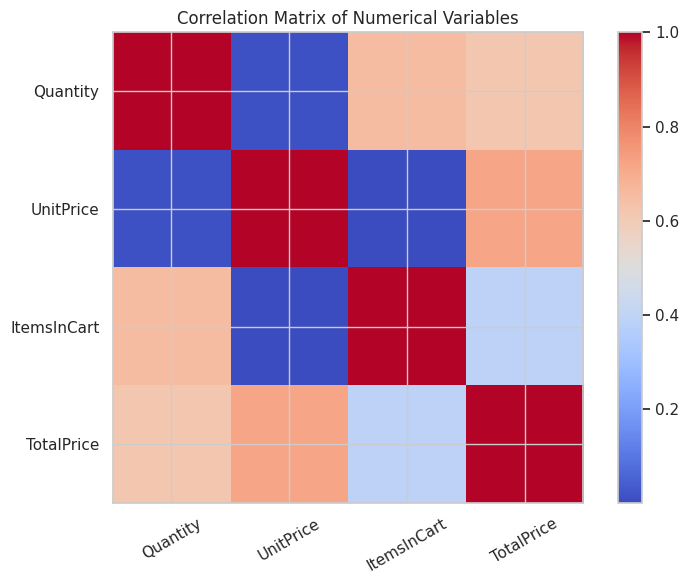

In [51]:
# Visualize correlation matrix

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap='coolwarm')

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=30
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Matrix of Numerical Variables')

plt.tight_layout()
plt.show()

TotalPrice shows a strong positive correlation with UnitPrice (0.717) and a moderate-to-strong positive correlation with Quantity (0.615). ItemsInCart has a moderate positive correlation with TotalPrice (0.393). Quantity and UnitPrice have almost no correlation (0.015), indicating that the number of items purchased is largely independent of the unit price.

22. Find the Top Products by Quantity Sold

In [52]:
# Analyze quantity sold by product

product_quantity = df.groupby('Product').agg(
    Total_Quantity=('Quantity', 'sum'),
    Average_Quantity_Per_Order=('Quantity', 'mean'),
    Order_Count=('OrderID', 'count')
).sort_values('Total_Quantity', ascending=False)

product_quantity

,Total_Quantity,Average_Quantity_Per_Order,Order_Count
Product,,,
Chair,562,3.157303,178
Printer,542,2.994475,181
Laptop,535,3.092486,173
Desk,508,2.988235,170
Tablet,497,2.776536,179
Monitor,480,2.944785,163
Phone,411,2.634615,156


Chair was the highest-demand product by total quantity sold, with 562 units across 178 orders. Phone had the lowest total quantity sold at 411 units across 156 orders.

23. Customer-Level Analysis

In [53]:
# Customer-level analysis

customer_analysis = df.groupby('CustomerID').agg(
    Order_Count=('OrderID', 'count'),
    Total_Order_Value=('TotalPrice', 'sum'),
    Average_Order_Value=('TotalPrice', 'mean')
)

# Customers with the most orders
top_order_customers = customer_analysis.sort_values(
    'Order_Count',
    ascending=False
).head(10)

print("Top 10 Customers by Number of Orders:")
display(top_order_customers)

# Customers with highest total order value
top_value_customers = customer_analysis.sort_values(
    'Total_Order_Value',
    ascending=False
).head(10)

print("\nTop 10 Customers by Total Order Value:")
display(top_value_customers)

Top 10 Customers by Number of Orders:


,Order_Count,Total_Order_Value,Average_Order_Value
CustomerID,,,
C70659,2,1853.96,926.980
C98474,2,2175.34,1087.670
C91155,2,704.82,352.410
C35852,2,1248.39,624.195
C14847,2,1097.81,548.905
C94569,2,1675.35,837.675
C97593,2,2855.22,1427.610
C38840,2,5723.23,2861.615
C21191,2,647.77,323.885



Top 10 Customers by Total Order Value:


,Order_Count,Total_Order_Value,Average_Order_Value
CustomerID,,,
C38840,2,5723.23,2861.615
C57276,1,3456.40,3456.400
C67260,1,3390.80,3390.800
C13877,1,3384.90,3384.900
C18404,1,3370.20,3370.200
C16775,1,3353.75,3353.750
C65986,1,3352.40,3352.400
C47778,1,3334.00,3334.000
C59183,1,3322.55,3322.550


Customer activity is highly concentrated around single-order customers. Among the 1,189 unique customers, no customer placed more than two orders. Customer C38840 had the highest total order value at ₹5,723.23 from two orders, while several other high-value customers achieved their ranking through a single high-value order.

24. Find the Most Important Business Insights

In [54]:
# Final overall EDA metrics

print("===== FINAL EDA SUMMARY =====")

print("\nTotal Orders:", len(df))

print("Total Order Value: ₹", round(df['TotalPrice'].sum(), 2))

print("Average Order Value: ₹", round(df['TotalPrice'].mean(), 2))

print("Highest Order Value: ₹", round(df['TotalPrice'].max(), 2))

print("Lowest Order Value: ₹", round(df['TotalPrice'].min(), 2))

print("\nMost Frequently Ordered Product:",
      df['Product'].value_counts().idxmax())

print("Most Common Payment Method:",
      df['PaymentMethod'].value_counts().idxmax())

print("Most Common Order Status:",
      df['OrderStatus'].value_counts().idxmax())

print("Most Common Referral Source:",
      df['ReferralSource'].value_counts().idxmax())

print("Most Common Coupon Code:",
      df['CouponCode'].value_counts().idxmax())

===== FINAL EDA SUMMARY =====

Total Orders: 1200
Total Order Value: ₹ 1264761.96
Average Order Value: ₹ 1053.97
Highest Order Value: ₹ 3456.4
Lowest Order Value: ₹ 11.39

Most Frequently Ordered Product: Printer
Most Common Payment Method: Online
Most Common Order Status: Cancelled
Most Common Referral Source: Instagram
Most Common Coupon Code: FREESHIP


25. The Final Key Findings Table

In [55]:
key_findings = {
    'Metric': [
        'Total Orders',
        'Total Order Value',
        'Average Order Value',
        'Highest Order Value',
        'Lowest Order Value',
        'Most Ordered Product',
        'Highest Sales Product',
        'Highest Quantity Sold Product',
        'Most Common Payment Method',
        'Most Common Order Status',
        'Most Common Referral Source',
        'Most Common Coupon Code'
    ],

    'Finding': [
        '1,200',
        '₹1,264,761.96',
        '₹1,053.97',
        '₹3,456.40',
        '₹11.39',
        'Printer',
        'Chair',
        'Chair',
        'Online',
        'Cancelled',
        'Instagram',
        'FREESHIP'
    ]
}

final_findings = pd.DataFrame(key_findings)

display(final_findings)

,Metric,Finding
0,Total Orders,"1,200"
1,Total Order Value,"₹1,264,761.96"
2,Average Order Value,"₹1,053.97"
3,Highest Order Value,"₹3,456.40"
4,Lowest Order Value,₹11.39
5,Most Ordered Product,Printer
6,Highest Sales Product,Chair
7,Highest Quantity Sold Product,Chair
8,Most Common Payment Method,Online
9,Most Common Order Status,Cancelled
